<a href="https://colab.research.google.com/github/reddoma742/DTQEM-Negative-Time-Non-locality/blob/main/DTQEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DTQEM - Final Calibrated Model
t_obs = 1.00e-06 s
Γ0    = 1.20e-01 1/s
a     = 3.33e+00 1/s/K
Γ(T)  = Γ0 + a·T
------------------------------------------------------------
Calibration verification:
  T=0K   → v = 1.00e+07 c
  T=300K → v = 1.20e+03 c


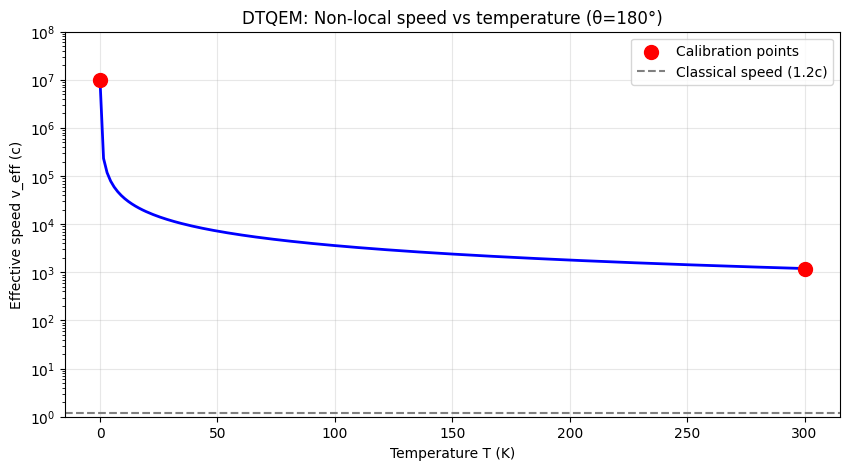

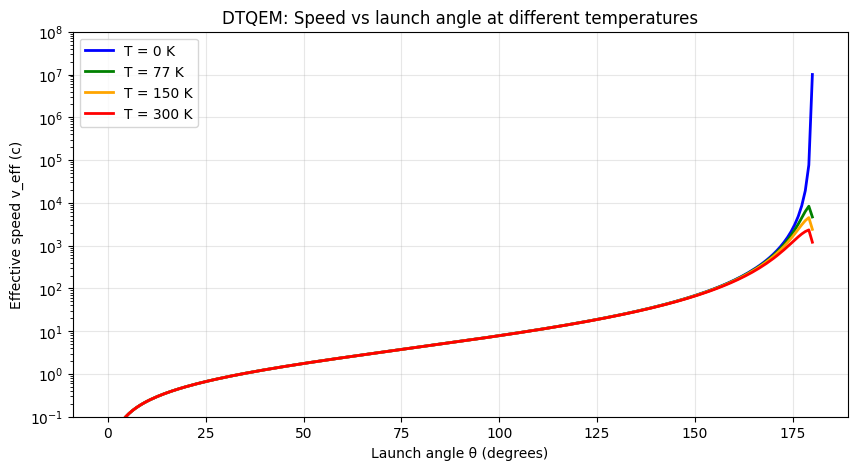

In [2]:

"""
DTQEM - Dual-Time Quantum Entanglement Model
Final Calibrated Version

This model assumes each particle has two times: real time (t_r)
and negative imaginary time (t_v). The effective speed of quantum
non-locality depends on temperature T and observation time t_obs.
"""

import numpy as np
import matplotlib.pyplot as plt

class DTQEM:
    """
    Dual-Time Quantum Entanglement Model
    Calibrated against Gisin et al. (1998) lower bound: 10^7 c at 0K
    """
    def __init__(self, t_obs=1e-6):
        """
        Parameters:
        -----------
        t_obs : float, observation time in seconds (default: 1 microsecond)
        """
        self.t_obs = t_obs
        # Calibration constants (derived analytically)
        self.Gamma0 = 1.2e-7 / t_obs      # decoherence at T=0K
        self.a = 3.3346e-6 / t_obs        # linear thermal coefficient
        # Physical constants
        self.c = 299792.458                # speed of light (km/s)
        self.v_classic_180 = 1.2           # classical speed at 180° (in units of c)

    def Gamma(self, T):
        """Thermal decoherence coefficient"""
        return self.Gamma0 + self.a * T

    def K_eff(self, T):
        """Effective observation switch (0 = observed, 1 = quantum)"""
        return np.exp(-self.Gamma(T) * self.t_obs)

    def v_eff(self, theta_deg, T):
        """
        Effective speed in units of c.

        Parameters:
        -----------
        theta_deg : float, launch angle between particles (0° to 180°)
        T : float, temperature in Kelvin

        Returns:
        --------
        float : effective speed (as multiple of c)
        """
        a_val = np.sin(np.radians(theta_deg) / 2.0)
        if a_val == 0:
            return 0.0
        # Base speed at 180° and given T
        v_base = self.v_classic_180 / (1 - a_val * self.K_eff(T))
        # Scale by classical speed for other angles
        v_classic_theta = 2 * self.v_classic_180 * a_val
        return v_base * (v_classic_theta / self.v_classic_180) if theta_deg != 180 else v_base

    def calibrate_from_experiment(self, T1, v1_c, T2, v2_c):
        """
        Re-calibrate the model using two experimental data points.

        Parameters:
        -----------
        T1, T2 : float, temperatures in Kelvin
        v1_c, v2_c : float, effective speeds (in units of c) at those temperatures
        """
        # Solve for Gamma_tobs = Gamma * t_obs using the formula:
        # v = 1.2 / (1 - exp(-Gamma_tobs)) => Gamma_tobs = -ln(1 - 1.2/v)
        Gamma_tobs1 = -np.log(1 - self.v_classic_180 / v1_c)
        Gamma_tobs2 = -np.log(1 - self.v_classic_180 / v2_c)

        # Gamma_tobs = (Gamma0 + a*T) * t_obs
        # So: Gamma0*t_obs = Gamma_tobs1
        # and: a*t_obs = (Gamma_tobs2 - Gamma_tobs1) / (T2 - T1)
        self.Gamma0 = Gamma_tobs1 / self.t_obs
        self.a = (Gamma_tobs2 - Gamma_tobs1) / (self.t_obs * (T2 - T1))
        return self.Gamma0, self.a

    def summary(self):
        """Print model parameters and calibration verification"""
        print("="*60)
        print("DTQEM - Final Calibrated Model")
        print(f"t_obs = {self.t_obs:.2e} s")
        print(f"Γ0    = {self.Gamma0:.2e} 1/s")
        print(f"a     = {self.a:.2e} 1/s/K")
        print(f"Γ(T)  = Γ0 + a·T")
        print("-"*60)
        print("Calibration verification:")
        print(f"  T=0K   → v = {self.v_eff(180,0):.2e} c")
        print(f"  T=300K → v = {self.v_eff(180,300):.2e} c")
        print("="*60)


# ======================================================================
# Demo and plotting
# ======================================================================

if __name__ == "__main__":
    # Initialize model with default t_obs = 1 microsecond
    model = DTQEM(t_obs=1e-6)
    model.summary()

    # Speed vs temperature at θ = 180°
    T_range = np.linspace(0, 300, 200)
    v_range = [model.v_eff(180, T) for T in T_range]

    plt.figure(figsize=(10, 5))
    plt.plot(T_range, v_range, 'b-', linewidth=2)
    plt.scatter([0, 300], [model.v_eff(180, 0), model.v_eff(180, 300)],
                color='red', s=100, zorder=5, label='Calibration points')
    plt.axhline(y=model.v_classic_180, color='gray', linestyle='--',
                label=f'Classical speed ({model.v_classic_180}c)')
    plt.yscale('log')
    plt.ylim(1, 1e8)
    plt.xlabel('Temperature T (K)')
    plt.ylabel('Effective speed v_eff (c)')
    plt.title('DTQEM: Non-local speed vs temperature (θ=180°)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Speed vs angle at different temperatures
    theta_range = np.linspace(0, 180, 200)
    plt.figure(figsize=(10, 5))
    colors = ['blue', 'green', 'orange', 'red']
    for T, color in zip([0, 77, 150, 300], colors):
        v_theta = [model.v_eff(theta, T) for theta in theta_range]
        plt.plot(theta_range, v_theta, color=color, label=f'T = {T} K', linewidth=2)
    plt.xlabel('Launch angle θ (degrees)')
    plt.ylabel('Effective speed v_eff (c)')
    plt.title('DTQEM: Speed vs launch angle at different temperatures')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.ylim(0.1, 1e8)
    plt.show()